In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
data = pd.read_csv("heart.csv")

In [5]:
data

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1020,59,1,1,140,221,0,1,164,1,0.0,2,0,2,1
1021,60,1,0,125,258,0,0,141,1,2.8,1,1,3,0
1022,47,1,0,110,275,0,0,118,1,1.0,1,1,2,0
1023,50,0,0,110,254,0,0,159,0,0.0,2,0,2,1


In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [7]:
#1.1 Checking Missing Values
data.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [8]:
#Checking Dupliactes
data.duplicated().sum()

np.int64(723)

In [9]:
data = data.drop_duplicates()

In [10]:
#Checking Datatypes
data.dtypes

,0
age,int64
sex,int64
cp,int64
trestbps,int64
chol,int64
fbs,int64
restecg,int64
thalach,int64
exang,int64
oldpeak,float64


In [11]:
#statisstics
data.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,302.00000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000
mean,54.42053,0.682119,0.963576,131.602649,246.500000,0.149007,0.526490,149.569536,0.327815,1.043046,1.397351,0.718543,2.314570,0.543046
std,9.04797,0.466426,1.032044,17.563394,51.753489,0.356686,0.526027,22.903527,0.470196,1.161452,0.616274,1.006748,0.613026,0.498970
min,29.00000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.00000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.250000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.50000,1.000000,1.000000,130.000000,240.500000,0.000000,1.000000,152.500000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.00000,1.000000,2.000000,140.000000,274.750000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.00000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [12]:
#columns
col = data.columns
col

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')

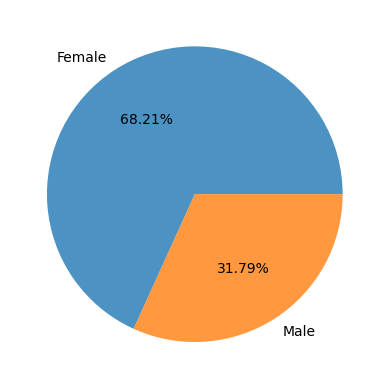

In [13]:
#checking gender
plt.pie(data['sex'].value_counts(),labels=['Female', 'Male'], autopct='%.2f%%', wedgeprops=dict(alpha=0.8))
plt.show()

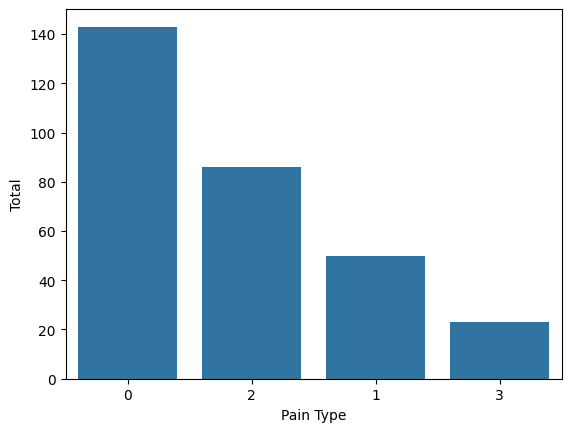

In [14]:
#Checking Chest Pain Specifications
sns.countplot(x='cp',data=data,order=data['cp'].value_counts().index)
plt.xlabel('Pain Type')
plt.ylabel('Total')
plt.show()

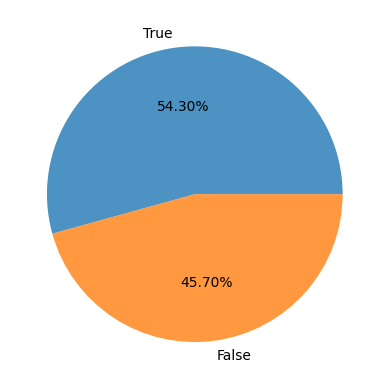

In [15]:
#target variable
plt.pie(data['target'].value_counts(),labels=['True', 'False'], autopct='%.2f%%', wedgeprops=dict(alpha=0.8))
plt.show()

In [16]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, precision_score, recall_score, f1_score, confusion_matrix

In [17]:
x = data.drop('target',axis=1)

y = data["target"]

In [18]:
#all columns except target
x

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
723,68,0,2,120,211,0,0,115,0,1.5,1,0,2
733,44,0,2,108,141,0,1,175,0,0.6,1,0,2
739,52,1,0,128,255,0,1,161,1,0.0,2,1,3
843,59,1,3,160,273,0,0,125,0,0.0,2,0,2


In [19]:
#target
y

,target
0,0
1,0
2,0
3,0
4,0
...,...
723,1
733,1
739,0
843,0


In [20]:
x_train , x_test , y_train , y_test = train_test_split(x,y,test_size = 0.2,random_state = 42,stratify=y)

In [21]:
print(x.shape)
print("training part",x_train.shape)
print("testing part",x_test.shape)
print()
print(y.shape)
print("training_part",y_train.shape)
print("testing part",y_test.shape)

(302, 13)
training part (241, 13)
testing part (61, 13)

(302,)
training_part (241,)
testing part (61,)


In [22]:
scaler = StandardScaler()

x_train = scaler.fit_transform(x_train)

x_test  = scaler.transform(x_test)

In [23]:
model_name = "Logistic regression"
model = LogisticRegression()
model.fit(x_train, y_train)
y_pred_train = model.predict(x_train)
y_pred = model.predict(x_test)

# Evaluate the model
#train_accuracy = accuracy_score(x_train,y_pred_train)

print(f"Model: {model_name}")
print(classification_report(y_test, y_pred))


Model: Logistic regression
              precision    recall  f1-score   support

           0       0.81      0.75      0.78        28
           1       0.80      0.85      0.82        33

    accuracy                           0.80        61
   macro avg       0.80      0.80      0.80        61
weighted avg       0.80      0.80      0.80        61



In [24]:
model_name = "Random Forest"
model = RandomForestClassifier(n_estimators=20, random_state=12,max_depth=5)
model.fit(x_train, y_train)
y_pred_train = model.predict(x_train)
y_pred = model.predict(x_test)

# Evaluate the model
#train_accuracy = accuracy_score(x_train,y_pred_train)

print(f"Model: {model_name}")
print(classification_report(y_test, y_pred))
print("confusion_mat\n",confusion_matrix(y_test, y_pred))

Model: Random Forest
              precision    recall  f1-score   support

           0       0.71      0.79      0.75        28
           1       0.80      0.73      0.76        33

    accuracy                           0.75        61
   macro avg       0.75      0.76      0.75        61
weighted avg       0.76      0.75      0.75        61

confusion_mat
 [[22  6]
 [ 9 24]]


In [25]:
model_name = "XG Boost"
model =XGBClassifier(learning_rate=0.01, n_estimators=25, max_depth=15,gamma=0.6, subsample=0.52,colsample_bytree=0.6,seed=27,
                    reg_lambda=2, booster='dart', colsample_bylevel=0.6, colsample_bynode=0.5)
model.fit(x_train, y_train)
y_pred_train = model.predict(x_train)
y_pred = model.predict(x_test)

# Evaluate the model
#train_accuracy = accuracy_score(x_train,y_pred_train)

print(f"Model: {model_name}")
print(classification_report(y_test, y_pred))
print("confusion_mat\n",confusion_matrix(y_test, y_pred))

Model: XG Boost
              precision    recall  f1-score   support

           0       0.92      0.43      0.59        28
           1       0.67      0.97      0.79        33

    accuracy                           0.72        61
   macro avg       0.79      0.70      0.69        61
weighted avg       0.78      0.72      0.70        61

confusion_mat
 [[12 16]
 [ 1 32]]


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [02:08:06] WARNING: /__w/xgboost/xgboost/src/learner.cc:341: `booster=dart` is deprecated. Use the tree booster directly with dropout parameters like `rate_drop`, `skip_drop`, or `one_drop`.
  bst.update(dtrain, iteration=i, fobj=obj)


In [26]:
model_name = "KNN"
model = KNeighborsClassifier(n_neighbors=10)
model.fit(x_train, y_train)
y_pred_train = model.predict(x_train)
y_pred = model.predict(x_test)

# Evaluate the model
#train_accuracy = accuracy_score(x_train,y_pred_train)

print(f"Model: {model_name}")
print(classification_report(y_test, y_pred))
print("confusion_mat\n",confusion_matrix(y_test, y_pred))

Model: KNN
              precision    recall  f1-score   support

           0       0.79      0.79      0.79        28
           1       0.82      0.82      0.82        33

    accuracy                           0.80        61
   macro avg       0.80      0.80      0.80        61
weighted avg       0.80      0.80      0.80        61

confusion_mat
 [[22  6]
 [ 6 27]]


In [27]:
model_name = "Decision Tree"
model = DecisionTreeClassifier(criterion = 'entropy',random_state=0,max_depth = 6)
model.fit(x_train, y_train)
y_pred_train = model.predict(x_train)
y_pred = model.predict(x_test)

# Evaluate the model
#train_accuracy = accuracy_score(x_train,y_pred_train)

print(f"Model: {model_name}")
print(classification_report(y_test, y_pred))
print("confusion_mat\n",confusion_matrix(y_test, y_pred))

Model: Decision Tree
              precision    recall  f1-score   support

           0       0.65      0.79      0.71        28
           1       0.78      0.64      0.70        33

    accuracy                           0.70        61
   macro avg       0.71      0.71      0.70        61
weighted avg       0.72      0.70      0.70        61

confusion_mat
 [[22  6]
 [12 21]]


In [28]:
model_name = "SVM"
model = SVC(kernel='rbf', C=2)
model.fit(x_train, y_train)
y_pred_train = model.predict(x_train)
y_pred = model.predict(x_test)

# Evaluate the model
#train_accuracy = accuracy_score(x_train,y_pred_train)

print(f"Model: {model_name}")
print(classification_report(y_test, y_pred))
print("confusion_mat\n",confusion_matrix(y_test, y_pred))

Model: SVM
              precision    recall  f1-score   support

           0       0.77      0.71      0.74        28
           1       0.77      0.82      0.79        33

    accuracy                           0.77        61
   macro avg       0.77      0.77      0.77        61
weighted avg       0.77      0.77      0.77        61

confusion_mat
 [[20  8]
 [ 6 27]]


In [ ]:
#           Model  Train Accuracy  Test Accuracy  Precision  Recall  F1 Score
# 0      Logistic           0.859          0.803      0.800   0.848     0.824
# 1  RandomForest           0.959          0.803      0.818   0.818     0.818
# 2           SVM           0.942          0.770      0.771   0.818     0.794
# 3       XGBoost           0.780          0.770      0.711   0.970     0.821
# 4           KNN           0.876          0.803      0.818   0.818     0.818
# 5  DecisionTree           0.954          0.705      0.778   0.636     0.700

In [29]:
import pickle

# Train Logistic Regression
model = LogisticRegression()
model.fit(x_train, y_train)

# Save model
pickle.dump(model, open("heart_model.pkl", "wb"))

# Save scaler
pickle.dump(scaler, open("scaler.pkl", "wb"))

print("Model Saved Successfully!")

Model Saved Successfully!
